In [15]:
import os
os.environ["AI2POT_PATH"] = "/data/home/liuhanyu/mycode/AI2Pot/"
os.environ["AI2POT_TEST_DATA_PATH"] = os.path.join(os.environ.get("AI2POT_PATH"),
                                                   "test",
                                                   "test_data",
                                                   "XYZ")

from typing import List

from ase import Atoms
from ase.io import read as ase_read
from ase.io.trajectory import Trajectory

import numpy as np
import torch
from ai2pot.models.mtp.linear_mtp_utils import (LinearMtp4Extxyz,
                                                LinearMtpCalculator)

torch.set_num_threads(16)

# 1. `atoms.get_potential_energy()` && `atoms.get_forces()`

In [16]:
checkpoint_path: str = os.path.join(os.environ.get("AI2POT_PATH"),
                                    "lightning_logs",
                                    "linear_mtp",
                                    "version_34",
                                    "checkpoints",
                                    "epoch=146-step=3675.ckpt")
extxyz_path: str = os.path.join(os.environ.get("AI2POT_TEST_DATA_PATH"),
                                               "11_NEP_potential_PbTe",
                                               "train_m.xyz")
map_location: str = "cpu"
torch_float_dtype: torch._C.dtype = torch.float32


atoms: Atoms = ase_read(extxyz_path, index=":")[0]
linear_mtp_calculator: LinearMtpCalculator = LinearMtpCalculator(checkpoint_path=checkpoint_path,
                                                                 map_location="cpu",
                                                                 torch_float_dtype=torch_float_dtype)
atoms.calc = linear_mtp_calculator

print("LinearMtpCalculator Summary:")
print("----------------------------")
print("\t0. Calculator type =", type(atoms.calc))
print("\t1. Energy = {0:.3f} eV".format(atoms.get_potential_energy()))
print("\t2. forces.shape =", atoms.get_forces().shape)

LinearMtpCalculator Summary:
----------------------------
	0. Calculator type = <class 'ai2pot.models.mtp.linear_mtp_utils.LinearMtpCalculator'>
	1. Energy = -936.656 eV
	2. forces.shape = (250, 3)


# 2. Equation of state (EOS)

In [17]:
atoms: Atoms = ase_read(extxyz_path, index=":")[0]
linear_mtp_calculator: LinearMtpCalculator = LinearMtpCalculator(checkpoint_path=checkpoint_path,
                                                                 map_location="cpu",
                                                                 torch_float_dtype=torch_float_dtype)
atoms.calc = linear_mtp_calculator

cell: np.ndarray = atoms.get_cell()
traj = Trajectory('PbTe.traj', 'w')
for x in np.linspace(0.85, 1.05, 9):
    atoms.set_cell(cell * x, scale_atoms=True)
    atoms.get_potential_energy()
    traj.write(atoms)

64.9682897204357 GPa


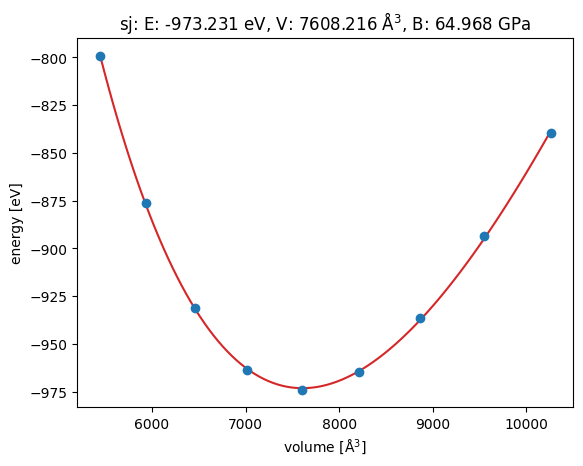

<Axes: title={'center': 'sj: E: -973.231 eV, V: 7608.216 Å$^3$, B: 64.968 GPa'}, xlabel='volume [Å$^3$]', ylabel='energy [eV]'>

In [18]:
from ase.eos import EquationOfState
from ase.io import read
from ase.units import kJ

configs = read('PbTe.traj@0:9')  # read 9 configurations
# Extract volumes and energies:
volumes = [atoms.get_volume() for atoms in configs]
energies = [atoms.get_potential_energy() for atoms in configs]
eos = EquationOfState(volumes, energies)
v0, e0, B = eos.fit()
print(B / kJ * 1.0e24, 'GPa')
eos.plot('PbTe-eos.png', show=True)

# 3. Molecular dynamics

In [19]:
from ase import units
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.verlet import VelocityVerlet

atoms: Atoms = ase_read(extxyz_path, index=":")[0]
linear_mtp_calculator: LinearMtpCalculator = LinearMtpCalculator(checkpoint_path=checkpoint_path,
                                                                 map_location="cpu",
                                                                 torch_float_dtype=torch_float_dtype)
atoms.calc = linear_mtp_calculator

# Set the momenta corresponding to T=300K
MaxwellBoltzmannDistribution(atoms, temperature_K=300)

# We want to run MD with constant energy using the VelocityVerlet algorithm.
dyn = VelocityVerlet(atoms, 1 * units.fs)  # 1 fs time step.

def printenergy(a):
    """Function to print the potential, kinetic and total energy"""
    epot = a.get_potential_energy() / len(a)
    ekin = a.get_kinetic_energy() / len(a)
    print(
        'Energy per atom: Epot = %.3feV  Ekin = %.3feV (T=%3.0fK)  '
        'Etot = %.3feV' % (epot, ekin, ekin / (1.5 * units.kB), epot + ekin)
    )

# Now run the dynamics
printenergy(atoms)
for i in range(1):
    dyn.run(10)
    printenergy(atoms)

Energy per atom: Epot = -3.747eV  Ekin = 0.037eV (T=284K)  Etot = -3.710eV
Energy per atom: Epot = -3.747eV  Ekin = 0.037eV (T=289K)  Etot = -3.710eV


# 4. Structure relaxation

In [20]:
from ase.optimize import BFGS

atoms: Atoms = ase_read(extxyz_path, index=":")[0]
linear_mtp_calculator: LinearMtpCalculator = LinearMtpCalculator(checkpoint_path=checkpoint_path,
                                                                 map_location="cpu",
                                                                 torch_float_dtype=torch_float_dtype)
atoms.calc = linear_mtp_calculator

opt = BFGS(atoms, trajectory='PbTe_opt.traj', logfile='PbTe_opt.log')
opt.run(fmax=0.1)

True

In [21]:
configs = ase_read("PbTe_opt.traj@0:10", 'r')
energies = [tmp_atoms.get_potential_energy() for tmp_atoms in configs]
print(energies)

[-936.6559448242188, -938.5125732421875, -947.6104736328125, -951.2482299804688, -952.0978393554688, -952.6817626953125, -953.7477416992188, -954.984130859375, -956.1403198242188, -956.6168212890625]
